**Note:** to inpute column `Transaction Data` you should use the `ffill()` function, what does it do? Split the resulting column into year, month and day.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df = df.replace("UNKNOWN", pd.NA)
df = df.replace("ERROR", pd.NA)

In [4]:
df.isna().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [5]:
df["Quantity"] = df["Quantity"].astype("Int8")
df[["Price Per Unit", "Total Spent"]] = df[["Price Per Unit", "Total Spent"]].astype("Float32")

In [6]:
df["Item"] = df["Item"].fillna(df["Item"].mode()[0])
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])
df["Transaction Date"] = df["Transaction Date"].ffill()

In [7]:
df['Payment Method'].value_counts()

Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

In [8]:
df["Payment Method"]= df["Payment Method"].ffill()

In [9]:
df.groupby("Item")["Price Per Unit"].value_counts()

Item      Price Per Unit
Cake      3.0               1085
Coffee    2.0               1108
Cookie    1.0               1026
Juice     3.0               1344
          4.0                213
          5.0                122
          2.0                119
          1.0                117
          1.5                110
Salad     5.0               1082
Sandwich  4.0               1082
Smoothie  4.0               1036
Tea       1.5               1023
Name: count, dtype: Int64

In [10]:
df["Price Per Unit"] = df["Price Per Unit"].fillna(df.groupby("Item")["Price Per Unit"].transform(lambda x: x.mode()[0]))

array([[<Axes: title={'center': 'Cake'}>,
        <Axes: title={'center': 'Coffee'}>,
        <Axes: title={'center': 'Cookie'}>],
       [<Axes: title={'center': 'Juice'}>,
        <Axes: title={'center': 'Salad'}>,
        <Axes: title={'center': 'Sandwich'}>],
       [<Axes: title={'center': 'Smoothie'}>,
        <Axes: title={'center': 'Tea'}>, <Axes: >]], dtype=object)

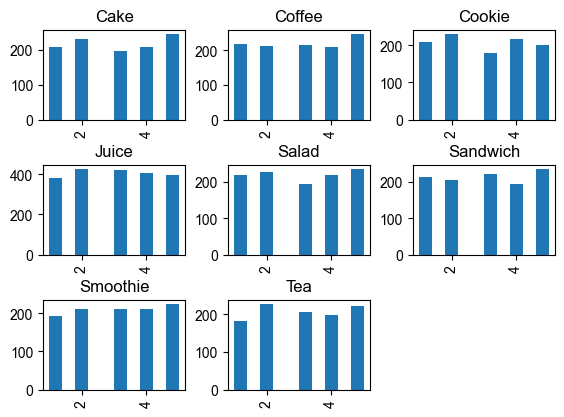

In [11]:
df.hist(column="Quantity", by="Item")

In [12]:
df["Quantity"] = df["Quantity"].fillna(df.groupby("Item")["Quantity"].transform(lambda x: round(x.mean())))

In [13]:
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

In [14]:
df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [15]:
df["Year"] = pd.to_datetime(df["Transaction Date"]).dt.year
df["Month"] = pd.to_datetime(df["Transaction Date"]).dt.month   
df["Day"] = pd.to_datetime(df["Transaction Date"]).dt.day
df = df.drop(columns=["Transaction Date"])

In [16]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Year,Month,Day
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023,9,8
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023,5,16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023,7,19
3,TXN_7034554,Salad,2,5.0,10.0,Credit Card,Takeaway,2023,4,27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023,6,11


In [18]:
df_encoded = pd.get_dummies(df, columns=["Item", "Payment Method", "Location"], drop_first=True)

In [40]:
df_encoded.head()

,Transaction ID,Quantity,Price Per Unit,Total Spent,Year,Month,Day,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway
0,TXN_1961373,2,2.0,4.0,2023,9,8,True,False,False,False,False,False,False,True,False,True
1,TXN_4977031,4,3.0,12.0,2023,5,16,False,False,False,False,False,False,False,False,False,False
2,TXN_4271903,4,1.0,4.0,2023,7,19,False,True,False,False,False,False,False,True,False,False
3,TXN_7034554,2,5.0,10.0,2023,4,27,False,False,False,True,False,False,False,True,False,True
4,TXN_3160411,2,2.0,4.0,2023,6,11,True,False,False,False,False,False,False,False,True,False


In [21]:
from sklearn.model_selection import train_test_split

# X = Features, y = Target/Label
X = df_encoded.drop('Quantity', axis=1) 
y = df_encoded['Quantity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=None 
)

f"Training set rows: {X_train.shape[0]} | Test set rows: {X_test.shape[0]}"

'Training set rows: 7000 | Test set rows: 3000'

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['Price Per Unit', 'Total Spent', 'Year', 'Month', 'Day']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [27]:
X_train.head()

,Transaction ID,Price Per Unit,Total Spent,Year,Month,Day,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway
9069,TXN_2430215,-1.522871,-1.163774,0.0,-0.735411,-0.654169,False,False,True,False,False,False,False,False,True,True
2603,TXN_4355766,-1.522871,-0.657030,0.0,1.289832,-0.996376,False,True,False,False,False,False,False,False,True,True
7738,TXN_5065748,0.043466,1.032117,0.0,0.132550,0.372452,False,False,False,False,False,False,False,True,False,False
1579,TXN_6712994,-0.739702,-0.488115,0.0,1.000511,-1.566721,True,False,False,False,False,False,False,False,False,True
5058,TXN_3975938,0.826634,0.525373,0.0,0.711191,-1.338583,False,False,False,False,True,False,False,True,False,True
